# Human Activity Recognition Using Hidden Markov Models

**Course:** Machine Learning — African Leadership University  
**Team:** Cedric Izabayo & Pauline  
**Date:** March 2026

---

## Overview

This notebook implements a Hidden Markov Model (HMM) to classify four human activities — **Standing, Walking, Jumping, and Still** — from smartphone accelerometer and gyroscope data collected at 100 Hz. We use the Baum-Welch algorithm for parameter estimation and Viterbi decoding for activity sequence prediction.

## 1. Setup and Imports

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy import stats
from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Activity labels
ACTIVITIES = ['standing', 'walking', 'jumping', 'still']
ACTIVITY_MAP = {a: i for i, a in enumerate(ACTIVITIES)}

DATA_DIR = 'data'
SAMPLING_RATE = 100  # Hz (sampleRateMs = 10ms)
TRIM_SECONDS = 1.0   # trim first and last 1 second

print('Setup complete.')

Setup complete.


## 2. Data Loading & Preprocessing

### 2.1 Data Collection Summary

Data was collected using the **phyphox** or similar sensor-logging app on two smartphones:

| Person | Device | Platform | Recordings | Sampling Rate |
|--------|--------|----------|------------|---------------|
| Cedric | iPhone 17 Pro | iOS 26.3 | 28 (7 per activity) | 100 Hz |
| Pauline | Sony SO-52C | Android | 25 (6-7 per activity) | 100 Hz |

Both phones record at **100 Hz** (10ms sample interval), so no resampling is needed. Each recording is approximately 10-12 seconds of a single activity.

**Naming conventions:**
- Cedric: `activity_N-timestamp` (e.g., `walking_1-2026-03-03_10-40-51`)
- Pauline: `activityN-timestamp` (e.g., `walking1-2026-03-03_10-55-33`)
- Known typo: `jumpimg4` in Pauline's data is treated as `jumping`

In [2]:
def extract_activity_label(folder_name):
    """
    Extract activity label from folder name.
    Handles both naming conventions and the 'jumpimg' typo.
    """
    name = folder_name.lower().split('-')[0]  # get part before first '-'
    # Remove trailing digits and underscores
    name = re.sub(r'[_]?\d+$', '', name)
    # Fix known typo
    if name == 'jumpimg':
        name = 'jumping'
    return name


def load_recording(folder_path):
    """
    Load accelerometer and gyroscope data from a recording folder.
    Merges on seconds_elapsed and trims first/last 1 second.
    """
    acc_path = os.path.join(folder_path, 'Accelerometer.csv')
    gyro_path = os.path.join(folder_path, 'Gyroscope.csv')
    
    if not os.path.exists(acc_path) or not os.path.exists(gyro_path):
        return None
    
    acc = pd.read_csv(acc_path)
    gyro = pd.read_csv(gyro_path)
    
    # Rename columns for clarity
    acc = acc.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
    gyro = gyro.rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})
    
    # Merge on seconds_elapsed using nearest merge (timestamps may not align exactly)
    merged = pd.merge_asof(
        acc[['seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']].sort_values('seconds_elapsed'),
        gyro[['seconds_elapsed', 'gyro_x', 'gyro_y', 'gyro_z']].sort_values('seconds_elapsed'),
        on='seconds_elapsed',
        direction='nearest',
        tolerance=0.015  # 15ms tolerance for 100Hz data
    )
    
    merged = merged.dropna()
    
    # Trim first and last 1 second to remove start/stop artifacts
    t_min = merged['seconds_elapsed'].min() + TRIM_SECONDS
    t_max = merged['seconds_elapsed'].max() - TRIM_SECONDS
    merged = merged[(merged['seconds_elapsed'] >= t_min) & (merged['seconds_elapsed'] <= t_max)].reset_index(drop=True)
    
    return merged


def load_metadata(folder_path):
    """
    Load device metadata from Metadata.csv.
    """
    meta_path = os.path.join(folder_path, 'Metadata.csv')
    if os.path.exists(meta_path):
        meta = pd.read_csv(meta_path)
        return {
            'device': meta['device name'].iloc[0],
            'platform': meta['platform'].iloc[0],
            'sample_rate_ms': meta['sampleRateMs'].iloc[0]
        }
    return {}


def load_all_data(data_dir):
    """
    Walk through all person directories and load all recordings.
    Returns a list of dicts with data, label, person, device info.
    """
    recordings = []
    
    for person in ['cedric', 'pauline']:
        person_dir = os.path.join(data_dir, person)
        if not os.path.isdir(person_dir):
            print(f'Warning: {person_dir} not found')
            continue
        
        for folder in sorted(os.listdir(person_dir)):
            folder_path = os.path.join(person_dir, folder)
            if not os.path.isdir(folder_path):
                continue
            
            activity = extract_activity_label(folder)
            if activity not in ACTIVITIES:
                print(f'Warning: Unknown activity "{activity}" in {folder}')
                continue
            
            data = load_recording(folder_path)
            if data is None or len(data) == 0:
                print(f'Warning: No data in {folder}')
                continue
            
            meta = load_metadata(folder_path)
            
            recordings.append({
                'data': data,
                'activity': activity,
                'activity_id': ACTIVITY_MAP[activity],
                'person': person,
                'folder': folder,
                'device': meta.get('device', 'unknown'),
                'platform': meta.get('platform', 'unknown'),
                'duration': data['seconds_elapsed'].max() - data['seconds_elapsed'].min(),
                'n_samples': len(data)
            })
    
    return recordings


# Load all data
recordings = load_all_data(DATA_DIR)
print(f'Loaded {len(recordings)} recordings successfully.')

Loaded 53 recordings successfully.


### 2.2 Summary Table

The rubric requires at least 1 minute 30 seconds of data per activity.

In [3]:
# Build summary DataFrame
summary_data = []
for r in recordings:
    summary_data.append({
        'Activity': r['activity'].capitalize(),
        'Person': r['person'].capitalize(),
        'Device': r['device'],
        'Duration (s)': round(r['duration'], 2),
        'Samples': r['n_samples']
    })

summary_df = pd.DataFrame(summary_data)

# Per-activity summary
activity_summary = summary_df.groupby('Activity').agg(
    Recordings=('Duration (s)', 'count'),
    Total_Duration_s=('Duration (s)', 'sum'),
    Mean_Duration_s=('Duration (s)', 'mean'),
    Total_Samples=('Samples', 'sum')
).round(2)

activity_summary['Total_Duration_min'] = (activity_summary['Total_Duration_s'] / 60).round(2)

print('=== Summary by Activity ===')
print(activity_summary)
print()

# Per-person summary
person_summary = summary_df.groupby(['Person', 'Activity']).agg(
    Recordings=('Duration (s)', 'count'),
    Total_Duration_s=('Duration (s)', 'sum')
).round(2)

print('=== Summary by Person and Activity ===')
print(person_summary)
print()

total_duration = summary_df['Duration (s)'].sum()
print(f'Total recordings: {len(recordings)}')
print(f'Total duration: {total_duration:.1f}s ({total_duration/60:.2f} min)')

=== Summary by Activity ===
          Recordings  Total_Duration_s  Mean_Duration_s  Total_Samples  \
Activity                                                                 
Jumping           14            115.64             8.26          11549   
Standing          13            106.37             8.18          10576   
Still             13            106.74             8.21          10660   
Walking           13            108.98             8.38          10876   

          Total_Duration_min  
Activity                      
Jumping                 1.93  
Standing                1.77  
Still                   1.78  
Walking                 1.82  

=== Summary by Person and Activity ===
                  Recordings  Total_Duration_s
Person  Activity                              
Cedric  Jumping            7             62.95
        Standing           7             62.76
        Still              7             62.00
        Walking            7             63.37
Pauline Jumping    

### 2.3 Visualize Raw Sensor Signals

We plot sample accelerometer and gyroscope signals for each of the 4 activities to understand the motion patterns. Distinct activities show different signal characteristics:
- **Standing:** Mild periodic sway in accelerometer, low gyroscope values
- **Walking:** Regular periodic patterns in both sensors
- **Jumping:** High-amplitude spikes in accelerometer, strong gyroscope rotation
- **Still:** Near-zero variance across all axes

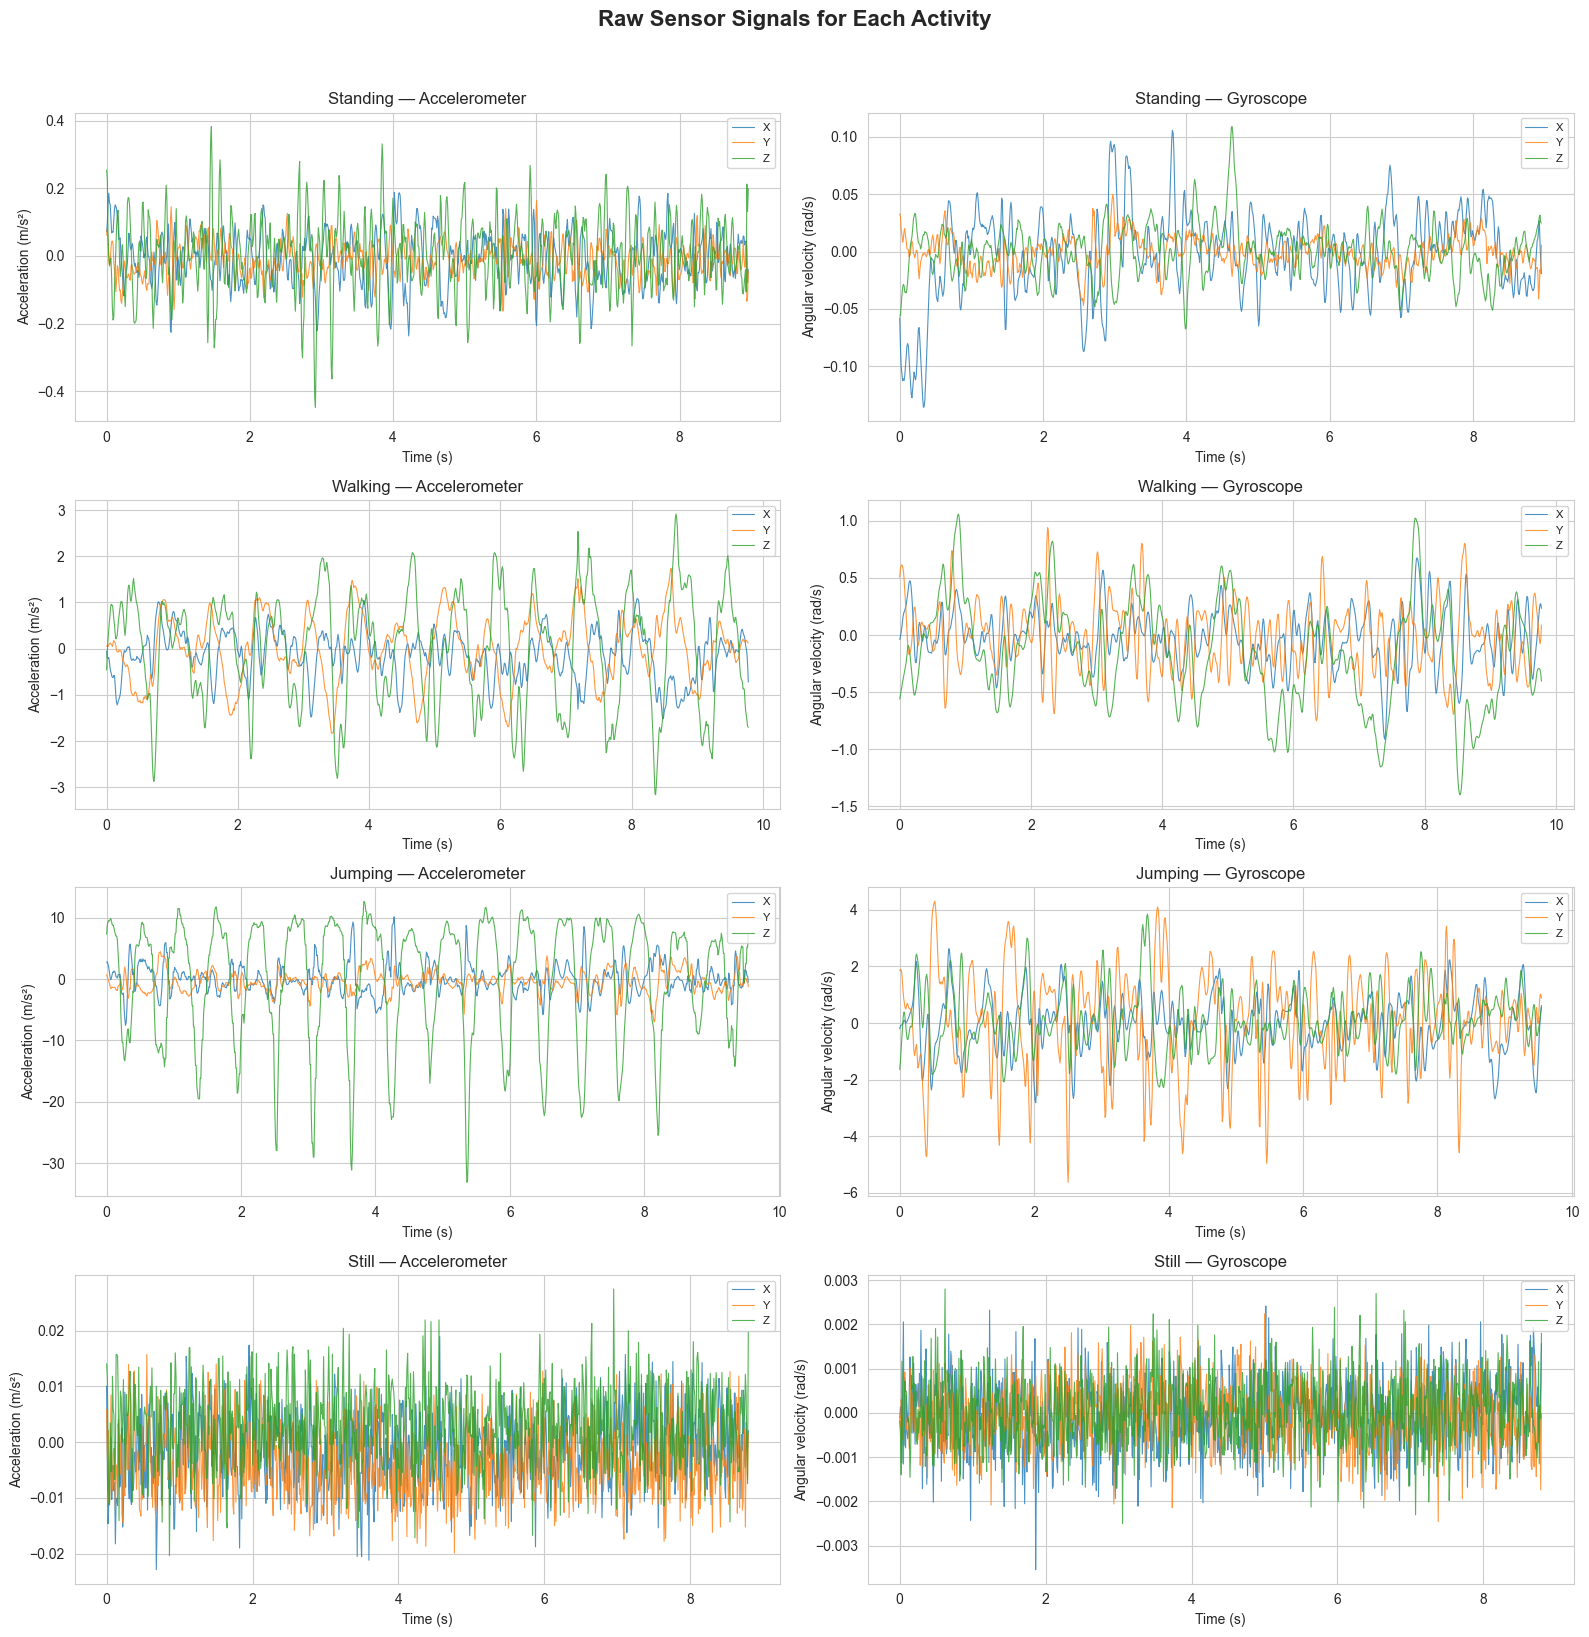

Saved: raw_signals.png


In [4]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
fig.suptitle('Raw Sensor Signals for Each Activity', fontsize=16, fontweight='bold', y=1.02)

for i, activity in enumerate(ACTIVITIES):
    # Pick a sample recording for this activity
    sample = [r for r in recordings if r['activity'] == activity][0]
    data = sample['data']
    t = data['seconds_elapsed'] - data['seconds_elapsed'].min()
    
    # Accelerometer
    ax_acc = axes[i, 0]
    ax_acc.plot(t, data['acc_x'], label='X', alpha=0.8, linewidth=0.8)
    ax_acc.plot(t, data['acc_y'], label='Y', alpha=0.8, linewidth=0.8)
    ax_acc.plot(t, data['acc_z'], label='Z', alpha=0.8, linewidth=0.8)
    ax_acc.set_title(f'{activity.capitalize()} — Accelerometer', fontsize=12)
    ax_acc.set_ylabel('Acceleration (m/s²)')
    ax_acc.legend(loc='upper right', fontsize=8)
    ax_acc.set_xlabel('Time (s)')
    
    # Gyroscope
    ax_gyro = axes[i, 1]
    ax_gyro.plot(t, data['gyro_x'], label='X', alpha=0.8, linewidth=0.8)
    ax_gyro.plot(t, data['gyro_y'], label='Y', alpha=0.8, linewidth=0.8)
    ax_gyro.plot(t, data['gyro_z'], label='Z', alpha=0.8, linewidth=0.8)
    ax_gyro.set_title(f'{activity.capitalize()} — Gyroscope', fontsize=12)
    ax_gyro.set_ylabel('Angular velocity (rad/s)')
    ax_gyro.legend(loc='upper right', fontsize=8)
    ax_gyro.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: raw_signals.png')

## 3. Feature Extraction

### 3.1 Sliding Window Approach

**Window size: 1 second (100 samples) with 50% overlap (50 samples).**

**Justification:** At 100 Hz, a 1-second window contains 100 samples, which is sufficient to capture:
- A full walking gait cycle (~1-2 steps per second)
- Multiple jumping impacts (~1-2 jumps per second)
- The steady-state nature of standing and still activities

A 50% overlap ensures smooth transitions between windows and avoids losing information at boundaries. This is a standard choice in activity recognition literature.

### 3.2 Feature Descriptions

We extract **5 features** per window from the 6-axis signal (3 accelerometer + 3 gyroscope):

#### Time-Domain Features:
1. **RMS (Root Mean Square) of accelerometer magnitude:** Captures the overall intensity of motion. Jumping produces high RMS due to large accelerations; still produces near-constant gravitational acceleration only. This is computed as the RMS of the Euclidean norm of the 3-axis accelerometer signal.

2. **Standard deviation of accelerometer magnitude:** Measures variability in motion intensity. Walking shows moderate, periodic variability; still shows near-zero variability. This complements RMS by distinguishing activities with similar average intensity but different dynamics.

3. **Signal Magnitude Area (SMA) of gyroscope:** Sum of absolute values across all 3 gyroscope axes, normalized by window length. This measures total rotational activity — walking and jumping involve significant body rotation, while standing and still have minimal rotation. SMA is a well-established feature in activity recognition.

#### Frequency-Domain Feature:
4. **Dominant frequency of accelerometer magnitude (via FFT):** We apply a Fast Fourier Transform (FFT) to the accelerometer magnitude signal and extract the frequency with the highest spectral power. Walking has a dominant frequency around 1-2 Hz (step frequency), jumping around 1-3 Hz (jump frequency), while standing and still have dominant frequencies near 0 Hz (no periodic motion). This feature directly captures the rhythmic nature of activities.

5. **Spectral energy of accelerometer magnitude:** Total energy in the frequency domain (sum of squared FFT magnitudes). High-energy activities (jumping, walking) produce larger spectral energy than low-energy ones (standing, still). This complements the dominant frequency by capturing overall activity intensity in the frequency domain.

### 3.3 Normalization

**Z-score normalization** (zero mean, unit variance) is applied to all features.

**Justification:** Our features have different units and scales (RMS in m/s², frequency in Hz, SMA in rad/s). Z-score normalization ensures all features contribute equally to the Gaussian emission model in the HMM, preventing features with larger magnitudes from dominating the distance calculations. It also centers the data around zero, which aligns well with the Gaussian distribution assumption in GaussianHMM.

In [5]:
WINDOW_SIZE = 100     # 1 second at 100 Hz
WINDOW_OVERLAP = 50   # 50% overlap
STEP_SIZE = WINDOW_SIZE - WINDOW_OVERLAP


def extract_features(data, sampling_rate=SAMPLING_RATE):
    """
    Extract features from a window of 6-axis sensor data.
    
    Parameters:
        data: DataFrame with columns acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z
        sampling_rate: sampling frequency in Hz
    
    Returns:
        numpy array of features: [acc_rms, acc_std, gyro_sma, dominant_freq, spectral_energy]
    """
    # Accelerometer magnitude
    acc_mag = np.sqrt(data['acc_x']**2 + data['acc_y']**2 + data['acc_z']**2)
    
    # Feature 1: RMS of accelerometer magnitude
    acc_rms = np.sqrt(np.mean(acc_mag**2))
    
    # Feature 2: Standard deviation of accelerometer magnitude
    acc_std = np.std(acc_mag)
    
    # Feature 3: Signal Magnitude Area (SMA) of gyroscope
    gyro_sma = (np.sum(np.abs(data['gyro_x'])) + 
                np.sum(np.abs(data['gyro_y'])) + 
                np.sum(np.abs(data['gyro_z']))) / len(data)
    
    # FFT of accelerometer magnitude
    n = len(acc_mag)
    fft_vals = fft(acc_mag.values - np.mean(acc_mag.values))  # remove DC component
    fft_mag = np.abs(fft_vals[:n // 2])  # one-sided spectrum
    freqs = fftfreq(n, d=1.0/sampling_rate)[:n // 2]
    
    # Feature 4: Dominant frequency
    if len(fft_mag) > 1:
        # Skip DC component (index 0)
        dominant_freq = freqs[1 + np.argmax(fft_mag[1:])]
    else:
        dominant_freq = 0.0
    
    # Feature 5: Spectral energy
    spectral_energy = np.sum(fft_mag**2) / n
    
    return np.array([acc_rms, acc_std, gyro_sma, dominant_freq, spectral_energy])


def extract_windows(recording, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """
    Apply sliding window to a recording and extract features for each window.
    
    Returns:
        features: numpy array of shape (n_windows, n_features)
        labels: numpy array of activity IDs for each window
    """
    data = recording['data']
    n_samples = len(data)
    features_list = []
    
    for start in range(0, n_samples - window_size + 1, step_size):
        window = data.iloc[start:start + window_size]
        feats = extract_features(window)
        features_list.append(feats)
    
    if not features_list:
        return np.array([]).reshape(0, 5), np.array([])
    
    features = np.array(features_list)
    labels = np.full(len(features_list), recording['activity_id'])
    
    return features, labels


FEATURE_NAMES = ['ACC_RMS', 'ACC_STD', 'GYRO_SMA', 'Dominant_Freq', 'Spectral_Energy']
print(f'Window size: {WINDOW_SIZE} samples ({WINDOW_SIZE/SAMPLING_RATE}s)')
print(f'Step size: {STEP_SIZE} samples ({STEP_SIZE/SAMPLING_RATE}s overlap)')
print(f'Features: {FEATURE_NAMES}')

Window size: 100 samples (1.0s)
Step size: 50 samples (0.5s overlap)
Features: ['ACC_RMS', 'ACC_STD', 'GYRO_SMA', 'Dominant_Freq', 'Spectral_Energy']


In [6]:
# Extract features from all recordings
all_features = []
all_labels = []
all_recording_ids = []  # track which recording each window came from
all_persons = []

for idx, rec in enumerate(recordings):
    feats, labels = extract_windows(rec)
    if len(feats) > 0:
        all_features.append(feats)
        all_labels.append(labels)
        all_recording_ids.extend([idx] * len(feats))
        all_persons.extend([rec['person']] * len(feats))

X_all = np.vstack(all_features)
y_all = np.concatenate(all_labels).astype(int)
recording_ids = np.array(all_recording_ids)
persons = np.array(all_persons)

print(f'Total feature windows: {len(X_all)}')
print(f'Feature matrix shape: {X_all.shape}')
print(f'\nWindows per activity:')
for act in ACTIVITIES:
    n = np.sum(y_all == ACTIVITY_MAP[act])
    print(f'  {act.capitalize()}: {n}')

Total feature windows: 796


Feature matrix shape: (796, 5)

Windows per activity:
  Standing: 193
  Walking: 198
  Jumping: 212
  Still: 193


In [7]:
# Z-score normalization
scaler = StandardScaler()
X_all_normalized = scaler.fit_transform(X_all)

print('Feature statistics BEFORE normalization:')
for i, name in enumerate(FEATURE_NAMES):
    print(f'  {name}: mean={X_all[:, i].mean():.4f}, std={X_all[:, i].std():.4f}')

print('\nFeature statistics AFTER Z-score normalization:')
for i, name in enumerate(FEATURE_NAMES):
    print(f'  {name}: mean={X_all_normalized[:, i].mean():.4f}, std={X_all_normalized[:, i].std():.4f}')

Feature statistics BEFORE normalization:
  ACC_RMS: mean=4.0009, std=5.7174
  ACC_STD: mean=2.0352, std=3.2352
  GYRO_SMA: mean=0.9307, std=1.0822
  Dominant_Freq: mean=8.1533, std=11.4625
  Spectral_Energy: mean=730.3632, std=1573.8472

Feature statistics AFTER Z-score normalization:
  ACC_RMS: mean=0.0000, std=1.0000
  ACC_STD: mean=0.0000, std=1.0000
  GYRO_SMA: mean=-0.0000, std=1.0000
  Dominant_Freq: mean=-0.0000, std=1.0000
  Spectral_Energy: mean=0.0000, std=1.0000
